# Attend Infer Repeat

In this tutorial we will implement the model and inference strategy described in "Attend, Infer, Repeat:
Fast Scene Understanding with Generative Models" (AIR) [1] and apply it to the multi-mnist dataset.

In [20]:
import os
from collections import namedtuple
import pyro
import pyro.optim as optim
from pyro.infer import SVI, TraceGraph_ELBO
import pyro.distributions as dist
import pyro.poutine as poutine
import pyro.contrib.examples.multi_mnist as multi_mnist
import torch
import torch.nn as nn
from torch.nn.functional import relu, sigmoid, softplus, grid_sample, affine_grid
import numpy as np
from tqdm.auto import trange

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='notebook', style='dark', palette='deep', font='sans-serif', font_scale=1, color_codes=True)
plt.style.use('dark_background')

## Introduction

The model described in [1] is a generative model of scenes. In this tutorial we will use it to model images from a dataset that is similar to the multi-mnist dataset in [1]. Here are some data points from this data set:

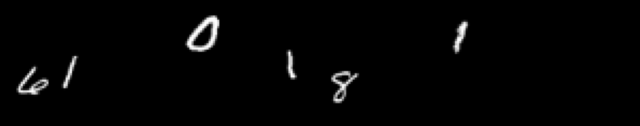

In [2]:
inpath = 'data'
X_np, _ = multi_mnist.load(inpath)
X_np = X_np.astype(np.float32)
X_np /= 255.0
mnist = torch.from_numpy(X_np)
def show_images(imgs):
    plt.figure(figsize=(8, 2))
    for i, img in enumerate(imgs):
        plt.subplot(1, len(imgs), i + 1)
        plt.axis('off')
        plt.imshow(img.data.numpy(), cmap='gray')
show_images(mnist[9:14])

## Model

### Generating a single object

At the core of the model is the generative process for a single object. Recall that:

* At each step a single object is generated.
* Each object is generated by passing its latent code through a neural network.
* We maintain uncertainty about the latent code used to generate each object, as well as its pose.

This can be expressed in Pyro like so:

In [3]:
# Create the neural network. This takes a latent code, z_what, to pixel intensities.
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(50, 200)
        self.l2 = nn.Linear(200, 400)

    def forward(self, z_what):
        h = relu(self.l1(z_what))
        return sigmoid(self.l2(h))

decode = Decoder()

z_where_prior_loc = torch.tensor([3., 0., 0.])
z_where_prior_scale = torch.tensor([0.1, 1., 1.])
z_what_prior_loc = torch.zeros(50)
z_what_prior_scale = torch.ones(50)

def prior_step_sketch(t):
    # Sample object pose. This is a 3-dimensional vector representing x,y position and size.
    z_where = pyro.sample('z_where_{}'.format(t),
                          dist.Normal(z_where_prior_loc.expand(1, -1),
                                      z_where_prior_scale.expand(1, -1))
                              .to_event(1))

    # Sample object code. This is a 50-dimensional vector.
    z_what = pyro.sample('z_what_{}'.format(t),
                         dist.Normal(z_what_prior_loc.expand(1, -1),
                                     z_what_prior_scale.expand(1, -1))
                             .to_event(1))
    
    # Map code to pixel space using the neural network.
    y_att = decode(z_what)

    # Position/scale object within larger image.
    y = object_to_image(z_where, y_att)

    return y

Hopefully the use of `pyro.sample` and PyTorch networks within a model seem familiar at this point. If not you might want to review the [VAE tutorial](vae.ipynb). One thing to note is that we include the current step `t` in the name passed to `pyro.sample` to ensure that names are unique across steps.

The `object_to_image` function is specific to this model and warrants further attention. Recall that the neural network (`decode` here) will output a small image, and that we would like to add this to the output image after performing any translation and scaling required to achieve the pose (location and size) described by `z_where`. It's not clear how to do this, and in particular it's not obvious that this can be implemented in a way that preserves the differentiability of our model, which we require in order to perform [SVI](svi_part_i.ipynb). However, it turns out we can do this this using a spatial transformer network (STN) [2].

Happily for us, PyTorch makes it easy to implement a STN using its [grid_sample](http://pytorch.org/docs/master/nn.html#grid-sample) and [affine_grid](http://pytorch.org/docs/master/nn.html#affine-grid) functions. `object_to_image` is a simple function that calls these, doing a little extra work to massage `z_where` into the expected format.

In [4]:
def expand_z_where(z_where):
    # Takes 3-dimensional vectors, and massages them into 2x3 matrices with elements like so:
    # [s,x,y] -> [[s,0,x],
    #             [0,s,y]]
    n = z_where.size(0)
    expansion_indices = torch.LongTensor([1, 0, 2, 0, 1, 3])
    out = torch.cat((torch.zeros([1, 1]).expand(n, 1), z_where), 1)
    return torch.index_select(out, 1, expansion_indices).view(n, 2, 3)

def object_to_image(z_where, obj):
    n = obj.size(0)
    theta = expand_z_where(z_where)
    grid = affine_grid(theta, torch.Size((n, 1, 50, 50)), align_corners=True)
    out = grid_sample(obj.view(n, 1, 20, 20), grid, align_corners=True)
    return out.view(n, 50, 50)

A discussion of the details of the STN is beyond the scope of this tutorial. For our purposes however, it suffices to keep in mind that `object_to_image` takes the small image generated by the neural network and places it within a larger image with the desired pose.

Let's visualize the results of calling `prior_step_sketch` a few times to clarify this:

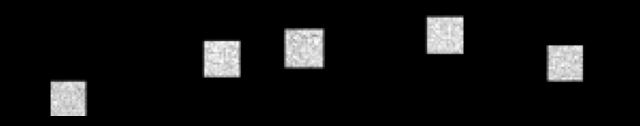

In [5]:
pyro.set_rng_seed(0)
samples = [prior_step_sketch(0)[0] for _ in range(5)]
show_images(samples)

### Generating an entire image

Having completed the implementation of a single step, we next consider how we can use this to generate an entire image. Recall that we would like to maintain uncertainty over the number of steps used to generate each data point. One choice we could make for the prior over the number of steps is the geometric distribution, which can be expressed as follows:

In [6]:
pyro.set_rng_seed(5)
def geom(num_trials=0):
    p = torch.tensor([0.5])
    x = pyro.sample('x{}'.format(num_trials), dist.Bernoulli(p))
    if x[0] == 1:
        return num_trials
    else:
        return geom(num_trials + 1)

# Generate some samples.
for _ in range(5):
    print('sampled {}'.format(geom()))

sampled 1
sampled 3
sampled 0
sampled 1
sampled 3


This is a direct translation of the definition of the geometric distribution as the number of failures before a success in a series of Bernoulli trials. Here we express this as a recursive function that passes around a counter representing the number of trials made, `num_trials`. This function samples from the Bernoulli and returns `num_trials` if `x == 1` (which represents success), otherwise it makes a recursive call, incrementing the counter.

The use of a geometric prior is appealing because it does not bound the number of steps the model can use a priori. It's also convenient, because by extending `geometric` to generate an object before each recursive call, we turn this from a geometric distribution over counts to a distribution over images with a geometrically distributed number of steps.

In [7]:
def geom_prior(x, step=0):
    p = torch.tensor([0.5])
    i = pyro.sample('i{}'.format(step), dist.Bernoulli(p))
    if i[0] == 1:
        return x
    else: 
        x = x + prior_step_sketch(step)
        return geom_prior(x, step + 1)

Let's visualize some samples from this distribution:

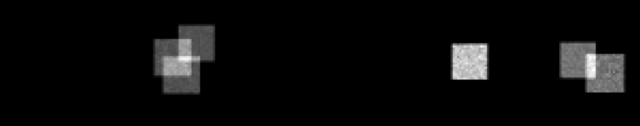

In [8]:
pyro.set_rng_seed(4123)
x_empty = torch.zeros(1, 50, 50)
samples = [geom_prior(x_empty)[0] for _ in range(5)]
show_images(samples)

#### Vectorized mini-batches

In [9]:
def prior_step(n, t, prev_x, prev_z_pres):

    # Sample variable indicating whether to add this object to the output.

    # We multiply the success probability of 0.5 by the value sampled for this
    # choice in the previous step. By doing so we add objects to the output until
    # the first 0 is sampled, after which we add no further objects.
    z_pres = pyro.sample('z_pres_{}'.format(t), 
                         dist.Bernoulli(0.5 * prev_z_pres)
                             .to_event(1))
    
    z_where = pyro.sample('z_where_{}'.format(t),
                          dist.Normal(z_where_prior_loc.expand(n, -1),
                                      z_where_prior_scale.expand(n, -1))
                              .mask(z_pres)
                              .to_event(1))

    z_what = pyro.sample('z_what_{}'.format(t),
                         dist.Normal(z_what_prior_loc.expand(n, -1),
                                     z_what_prior_scale.expand(n, -1))
                             .mask(z_pres)
                             .to_event(1))

    y_att = decode(z_what)
    y = object_to_image(z_where, y_att)

    # Combine the image generated at this step with the image so far.
    x = prev_x + y * z_pres.view(-1, 1, 1)

    return x, z_pres

By iterating this step function we can produce an entire image, composed of multiple objects. Since each image in the multi-mnist dataset contains zero, one or two digits we will allow the model to use up to (and including) three steps. In this way we ensure that inference has to avoid using one or more steps in order to correctly count the number of objects in the input.

In [10]:
def prior(n):
    x = torch.zeros(n, 50, 50)
    z_pres = torch.ones(n, 1)
    for t in range(3):
        x, z_pres = prior_step(n, t, x, z_pres)
    return x

def model(data):
    # Register network for optimization.
    pyro.module("decode", decode)
    with pyro.plate('data', data.size(0)) as indices:
        batch = data[indices]
        x = prior(batch.size(0)).view(-1, 50 * 50)
        sd = (0.3 * torch.ones(1)).expand_as(x)
        pyro.sample('obs', dist.Normal(x, sd).to_event(1),
                    obs=batch)

We have now fully specified the prior for our model. Let's visualize some samples to get a feel for this distribution:

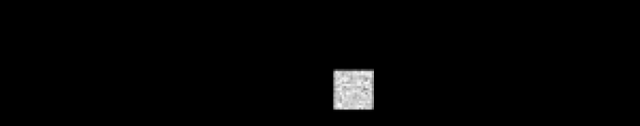

In [11]:
pyro.set_rng_seed(1245789)
show_images(prior(5))

## Guide

We will perform [amortized stochastic variational inference](svi_part_i.ipynb) in this model. Pyro provides general purpose machinery that implements most of this inference strategy, but as we have seen in earlier tutorials we are required to provide a model specific guide. What we call a guide in Pyro is exactly the entity called the "inference network" in the paper.

We will structure the guide around a recurrent network to allow the guide to capture (some of) the dependencies we expect to be present in the true posterior. At each step the recurrent network will generate the parameters for the choices made within the step. The values sampled will be fed back into the recurrent network so that this information can be used when computing the parameters for the next step. The guide for the [Deep Markov Model](dmm.ipynb) shares a similar structure.

As in the model, the core of the guide is the logic for a single step.

In [12]:
rnn = nn.LSTMCell(2554, 256)

# Takes pixel intensities of the attention window to parameters (mean,
# standard deviation) of the distribution over the latent code,
# z_what.
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(400, 200)
        self.l2 = nn.Linear(200, 100)

    def forward(self, data):
        h = relu(self.l1(data))
        a = self.l2(h)
        return a[:, 0:50], softplus(a[:, 50:])

encode = Encoder()

# Takes the guide RNN hidden state to parameters of
# the guide distributions over z_where and z_pres.
class Predict(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.l = nn.Linear(256, 7)

    def forward(self, h):
        a = self.l(h)
        z_pres_p = sigmoid(a[:, 0:1]) # Squish to [0,1]
        z_where_loc = a[:, 1:4]
        z_where_scale = softplus(a[:, 4:]) # Squish to >0
        return z_pres_p, z_where_loc, z_where_scale

predict = Predict()

def guide_step_improved(t, data, prev):

    rnn_input = torch.cat((data, prev.z_where, prev.z_what, prev.z_pres), 1)
    h, c = rnn(rnn_input, (prev.h, prev.c))
    z_pres_p, z_where_loc, z_where_scale = predict(h)

    z_pres = pyro.sample('z_pres_{}'.format(t),
                         dist.Bernoulli(z_pres_p * prev.z_pres)
                             .to_event(1))

    z_where = pyro.sample('z_where_{}'.format(t),
                          dist.Normal(z_where_loc, z_where_scale)
                              .to_event(1))

    # New. Crop a small window from the input.
    x_att = image_to_object(z_where, data)

    # Compute the parameter of the distribution over z_what
    # by passing the window through the encoder network.
    z_what_loc, z_what_scale = encode(x_att)

    z_what = pyro.sample(
        'z_what_{}'.format(t),
        dist.Normal(z_what_loc, z_what_scale).to_event(1)
    )

    return # values for next step

def z_where_inv(z_where):
    # Take a batch of z_where vectors, and compute their "inverse".
    # That is, for each row compute:
    # [s,x,y] -> [1/s,-x/s,-y/s]
    # These are the parameters required to perform the inverse of the
    # spatial transform performed in the generative model.
    n = z_where.size(0)
    out = torch.cat((torch.ones([1, 1]).type_as(z_where).expand(n, 1), -z_where[:, 1:]), 1)
    out = out / z_where[:, 0:1]
    return out

def image_to_object(z_where, image):
    n = image.size(0)
    theta_inv = expand_z_where(z_where_inv(z_where))
    grid = affine_grid(theta_inv, torch.Size((n, 1, 20, 20)))
    out = grid_sample(image.view(n, 1, 50, 50), grid)
    return out.view(n, -1)

## Inference

As we mentioned in the introduction, successfully performing inference in this model is a challenge. In particular, the presence of discrete choices in the model makes inference trickier than in a model in which all choices can be reparameterized. The underlying problem we face is that the gradient estimates we use in the optimization performed by variational inference have much higher variance in the presence of [non-reparameterizable choices](svi_part_iii.ipynb#Tricky-Case:-Non-reparameterizable-Random-Variables).

To bring this variance under control, the paper applies a technique called "data dependent baselines" (AKA "neural baselines") to the discrete choices in the model.

### Data dependent baselines

Happily for us, Pyro includes support for data dependent baselines. If you are not already familiar with this idea, you might want to read [our introduction](svi_part_iii.ipynb#Baselines-in-Pyro) before continuing. As model authors we only have to implement the neural network, pass it our data as input, and feed its output to `pyro.sample`. Pyro's inference back-end will ensure that the baseline is included in the gradient estimator used for inference, and that the network parameters are updated appropriately.

Let's see how we can add data dependent baselines to our AIR implementation. We need a neural network that can output a (scalar) baseline value at each discrete choice in the guide, having received a multi-mnist image and the values sampled by the guide so far as input. Notice that this is very similar to the structure of the guide network, and indeed we will again use a recurrent network.

To implement this we will first write a short helper function that implements a single step of the RNN we've just described:

In [13]:
bl_rnn = nn.LSTMCell(2554, 256)
bl_predict = nn.Linear(256, 1)

# Use an RNN to compute the baseline value. This network takes the
# input images and the values samples so far as input.
def baseline_step(x, prev):
    rnn_input = torch.cat((x,
                           prev.z_where.detach(),
                           prev.z_what.detach(),
                           prev.z_pres.detach()), 1)
    bl_h, bl_c = bl_rnn(rnn_input, (prev.bl_h, prev.bl_c))
    bl_value = bl_predict(bl_h) * prev.z_pres
    return bl_value, bl_h, bl_c

There are two important details to highlight here:

First, we `detach` values sampled by the guide before passing them to the baseline network. This is important as the baseline network and the guide network are entirely separate networks optimized with different objectives. Without this, gradients would flow from the baseline network into the guide network. When using data dependent baselines we must do this whenever we feed values sampled by the guide into the baselines network. (If we don't we'll trigger a PyTorch run-time error.)

Second, we multiply the output of the baseline network by the value of `z_pres` from the previous step. This relieves the baseline network from the burdon of having to output accurate predictions for completed samples. (The outputs for completed samples will be multiplied by zero, so the derivative of the [baseline loss](svi_part_iii.ipynb#Neural-Baselines) for these outputs will be zero.) It's OK to do this because in effect we've already removed random choices for completed samples from the inference objective, so there's no need to apply any variance reduction to them.

We now have everything we need to complete the implementation of the guide. Our final `guide_step` function will be very similar to `guide_step_improved` introduced above. The only changes are:

1. We now call the `baseline_step` helper and pass the baseline value it returns to `pyro.sample`.
2. We now mask out the `z_where` and `z_what` choices for complete sample. This serves exactly the same purpose as the masks added to the model. (See the earlier discussion for the motivation behind this change.)

We'll also write a `guide` function that will iterate `guide_step` in order to provide a guide for the whole model.

In [14]:
GuideState = namedtuple('GuideState', ['h', 'c', 'bl_h', 'bl_c', 'z_pres', 'z_where', 'z_what'])
def initial_guide_state(n):
    return GuideState(h=torch.zeros(n, 256),
                      c=torch.zeros(n, 256),
                      bl_h=torch.zeros(n, 256),
                      bl_c=torch.zeros(n, 256),
                      z_pres=torch.ones(n, 1),
                      z_where=torch.zeros(n, 3),
                      z_what=torch.zeros(n, 50))

def guide_step(t, data, prev):

    rnn_input = torch.cat((data, prev.z_where, prev.z_what, prev.z_pres), 1)
    h, c = rnn(rnn_input, (prev.h, prev.c))
    z_pres_p, z_where_loc, z_where_scale = predict(h)

    # Here we compute the baseline value, and pass it to sample.
    baseline_value, bl_h, bl_c = baseline_step(data, prev)
    z_pres = pyro.sample('z_pres_{}'.format(t),
                         dist.Bernoulli(z_pres_p * prev.z_pres)
                             .to_event(1),
                         infer=dict(baseline=dict(baseline_value=baseline_value.squeeze(-1))))

    z_where = pyro.sample('z_where_{}'.format(t),
                          dist.Normal(z_where_loc, z_where_scale)
                              .mask(z_pres)
                              .to_event(1))
    
    x_att = image_to_object(z_where, data)

    z_what_loc, z_what_scale = encode(x_att)

    z_what = pyro.sample('z_what_{}'.format(t),
                         dist.Normal(z_what_loc, z_what_scale)
                             .mask(z_pres)
                             .to_event(1))

    return GuideState(h=h, c=c, bl_h=bl_h, bl_c=bl_c, z_pres=z_pres, z_where=z_where, z_what=z_what)

def guide(data):
    # Register networks for optimization.
    pyro.module('rnn', rnn),
    pyro.module('predict', predict),
    pyro.module('encode', encode),
    pyro.module('bl_rnn', bl_rnn)
    pyro.module('bl_predict', bl_predict)

    with pyro.plate('data', data.size(0), subsample_size=64) as indices:
        batch = data[indices]
        state = initial_guide_state(batch.size(0))
        steps = []
        for t in range(3):
            state = guide_step(t, batch, state)
            steps.append(state)
        return steps

### Putting it all together

We have now completed the implementation of the model and the guide. As we have seen in earlier tutorials, we need write only a few more lines of code to begin performing inference:

  0%|          | 0/10000 [00:00<?, ?it/s]

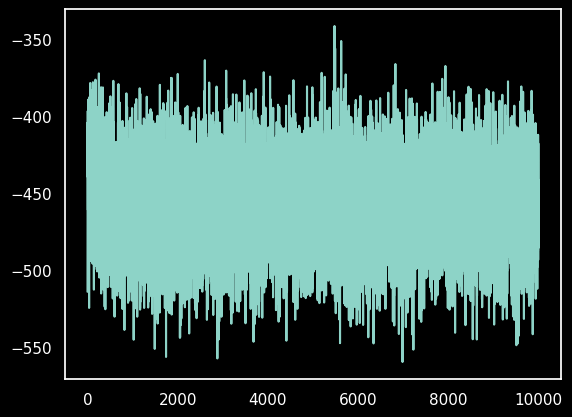

In [22]:
data = mnist.view(-1, 50 * 50)
svi = SVI(model, guide, optim.AdamW({'lr': 1e-4, 'weight_decay': 1e-3}), loss=TraceGraph_ELBO())

losses = []
for i in trange(10_000):
    loss = svi.step(data)
    losses.append(loss / data.size(0))

plt.plot(losses)

These results were collected using the following parameters:

```
python main.py -n 200000 -blr 0.1 --z-pres-prior 0.01 --scale-prior-sd 0.2 --predict-net 200 --bl-predict-net 200 --decoder-output-use-sigmoid --decoder-output-bias -2 --seed 287710
```

We used Pyro commit `c0b38ad` with PyTorch `0.2.0.post4`. Inference ran for approximately 4 hours on an NVIDIA K80 GPU. (Note that even though we set the random seed, this isn't sufficient to make inference deterministic when using CUDA.)

## In practice

We found it important to pay attention to the following details in order to achieve good results with AIR.

* Inference is unlikely to recover correct object counts unless a small prior success probability for `z_pres` is used. In [1] this [probability was annealed](http://akosiorek.github.io/ml/2017/09/03/implementing-air.html) from a value close to one to `1e-5` (or less) during optimization, though we found that a fixed value of around `0.01` worked well with our implementation.
* We initialize the decoder network to generate mostly empty objects initially. (Using the `--decoder-output-bias` argument.) This encourages the guide to explore the use of objects to explain the input early in optimization. Without this each object is a mid-gray square which is heavily penalized by the likelihood, prompting the guide to turn most steps off.
* It is reported to be useful in practice to use a different learning rate for the baseline network. This is straight forward to implement in Pyro by tagging modules associated with the baseline network and passing multiple learning rates to the optimizer. (See the section on [optimizers](svi_part_i.ipynb#Optimizers) in part I of the SVI tutorial for more detail.) In [1] a learning rate of `1e-4` was used for the guide network, and a learning rate of `1e-3` was used for the baseline network. We found it necessary to use a larger learning rate for the baseline network in order to make progress on count accuracy at a similar rate to [1]. This difference is likely caused by Pyro setting up a [slightly different baseline loss](https://github.com/pyro-ppl/pyro/issues/555).


## References

[1] `Attend, Infer, Repeat: Fast Scene Understanding with Generative Models`
<br />&nbsp;&nbsp;&nbsp;&nbsp;
S. M. Ali Eslami and Nicolas Heess and Theophane Weber and Yuval Tassa and Koray Kavukcuoglu and Geoffrey E. Hinton

[2] `Spatial Transformer Networks`
<br />&nbsp;&nbsp;&nbsp;&nbsp;
Max Jaderberg and Karen Simonyan and Andrew Zisserman